100%|██████████| 9.91M/9.91M [00:01<00:00, 6.01MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 163kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.51MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.48MB/s]


Epoch 1/25 - Loss: 319.79
Epoch 2/25 - Loss: 130.43
Epoch 3/25 - Loss: 90.27
Epoch 4/25 - Loss: 67.29
Epoch 5/25 - Loss: 52.78
Epoch 6/25 - Loss: 42.96
Epoch 7/25 - Loss: 34.03
Epoch 8/25 - Loss: 28.86
Epoch 9/25 - Loss: 22.68
Epoch 10/25 - Loss: 20.77
Epoch 11/25 - Loss: 16.03
Epoch 12/25 - Loss: 15.85
Epoch 13/25 - Loss: 12.97
Epoch 14/25 - Loss: 12.81
Epoch 15/25 - Loss: 10.56
Epoch 16/25 - Loss: 9.89
Epoch 17/25 - Loss: 9.44
Epoch 18/25 - Loss: 9.59
Epoch 19/25 - Loss: 6.93
Epoch 20/25 - Loss: 9.86
Epoch 21/25 - Loss: 8.44
Epoch 22/25 - Loss: 7.97
Epoch 23/25 - Loss: 7.03
Epoch 24/25 - Loss: 5.40
Epoch 25/25 - Loss: 7.76
Total accuracy: 97.71%
Model saved as mnist.pth


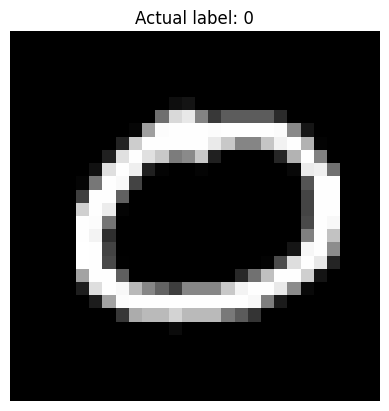

User picked image index : 69
Actual label            : 0
Model prediction        : 0


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# ---- TRANSFORMS ----
transform = transforms.ToTensor()

# ---- DATA ----
train_data = MNIST(root="data", train=True,  download=True, transform=transform)
test_data  = MNIST(root="data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=64, shuffle=False)


class digitmodel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,10)


            
        )
    def forward(self,x):
        return self.net(x)
model = digitmodel()
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr = 0.001)
epochs = 25
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for images, labels in train_loader:  # ← Bug 1 fixed!
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs,labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss:.2f}")
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs     = model(images)
        predictions = outputs.argmax(dim=1)
        correct    += (predictions == labels).sum().item()
        total      += labels.size(0)    # ← Bug 2 fixed!

accuracy = 100 * correct/total

print(f"Total accuracy: {accuracy:.2f}%")   # ← Bug 3 fixed!

# ---- SAVE ----
torch.save(model.state_dict(), "mnist.pth")
print("Model saved as mnist.pth")

# ---- VISUALIZE ONE PREDICTION ----
index = 69
image, true_label = test_data[index]

plt.imshow(image.squeeze(), cmap="gray")   # ← Bug 4 fixed!
plt.title(f"Actual label: {true_label}")
plt.axis("off")
plt.show()

# ---- PREDICT ONE IMAGE ----
image_flat = image.view(1, -1).to(device)  # ← Bug 5 fixed!

with torch.no_grad():
    output          = model(image_flat)
    predicted_label = output.argmax(dim=1).item()

print(f"User picked image index : {index}")
print(f"Actual label            : {true_label}")
print(f"Model prediction        : {predicted_label}")

In [2]:
## don't run on vs code locally